## Source Data
https://clearinghouse.isgs.illinois.edu/data/elevation/illinois-height-modernization-ilhmp

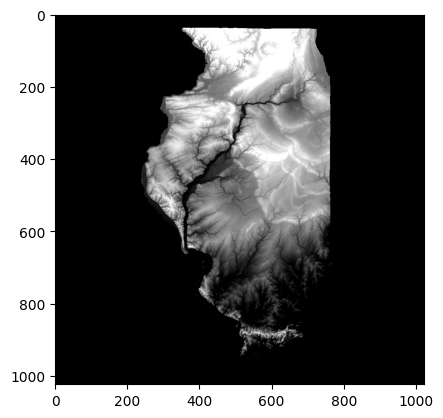

In [14]:
import matplotlib.pyplot as plt 

dem = plt.imread('IL_Statewide_Lidar_DEM_WGS.png')[:,:,0]
plt.imshow(dem, cmap='gray', vmin=0, vmax=1)

## Geometry Fundamentals
### 3D Vector
$\vec{u} = (\Delta x, \Delta y, \Delta z)$, 3 components.

### Dot product
Dot product of two vectors $\operatorname{dot}(\vec{a}, \vec{b})$ measure the "closeness" of the two vectors.

Imagine: `n = feet--torso-->head` and `l = shoulder--arm-->hand ... sun`. Dot products translates to soreness in your shoulder.
- **noon**: $\operatorname{dot}(\vec{n}, \vec{l})\approx 1$
- **morning/afternoon**: $0 < \operatorname{dot}(\vec{n}, \vec{l}) < 1$
- **dawn/dusk**: $\operatorname{dot}(\vec{n}, \vec{l}) \approx 0$
- **night**: $\operatorname{dot}(\vec{n}, \vec{l}) < 0$

All surfaces are similar to the Earth's surface. (GEOmetry!) The local days and nights serve as a visual cue for our 3D perception.

We need two things: a light direction $\vec{l}$ and a surface normal $\vec{n}$. We also need to normalize them first.

In [2]:
import numpy as np
from numba import njit, prange

@njit
def normalize(v):
    return v / np.linalg.norm(v)

## Light Direction

We use two angles $\theta$ and $\psi$ to describe the light direction:
$$\vec{l}(\theta, \psi) = \left(\cos\theta\cos\psi, \cos\theta\sin\psi, \sin\theta \right)$$
<img src="https://upload.wikimedia.org/wikipedia/commons/3/30/Plane_with_ENU_embedded_axes.svg" width="300">

In [3]:
@njit
def light(theta, psi):
    l = np.array([
        np.cos(np.radians(theta)) * np.cos(np.radians(psi)),
        np.cos(np.radians(theta)) * np.sin(np.radians(psi)),
        np.sin(np.radians(theta))
    ])
    return normalize(l)

## Surface Normal

### Cross product
$\operatorname{cross}(\vec{a}, \vec{b}) = \vec{a} \times \vec{b}$ is perpendicular to both $\vec{u}$ and $\vec{v}$.

<img src="https://upload.wikimedia.org/wikipedia/commons/d/d2/Right_hand_rule_cross_product.svg" width="400">

### Example: DEM
Let's focus on a hypothetical example around point $(i, j)$
```
                (i-1, j)
(i-1, j-1) ?--------4--------? (i-1, j+1)
           |        ^        |
           |        ^        |
  (i, j-1) 3>>>>>>(i,j)>>>>>>2 (i, j+1)
           |        ^        |
           |        ^        |
(i+1, j-1) ?--------1--------? (i+1, j+1)
                (i+1,j)
```

$$\vec{t}_x = (2, 0, dem[i, j+1] - dem[i, j-1]) = (2, 0, 2-3) = (2, 0, -1)$$
$$\vec{t}_y = (0, 2, dem[i-1, j] - dem[i+1, j]) = (0, 2, 4-1) = (0, 2, 3)$$
$$\vec{n} = \operatorname{cross}(\vec{t}_x, \vec{t}_y) = \operatorname{cross}((2, 0, -1), (0, 2, 3)) = (2, -6, 4)$$


<details>
  <summary>For the mathematically-inclined</summary>
A function $f(x,y)$ defines a surface
$$\vec{r}(x, y) = (x, y, f(x, y))^\top.$$
The tangent vectors are:
$$\frac{\partial \vec{r}}{\partial x}(x,y) = \left(1, 0, \frac{\partial f}{\partial x}(x, y)\right)^\top, \quad
\frac{\partial \vec{r}}{\partial y}(x,y) = \left(0, 1, \frac{\partial f}{\partial x}(x, y)\right)^\top.$$
The (unnormalized) normal vector is the cross product of the two:
$$\vec{n}(x,y) = \frac{\partial \vec{r}}{\partial x}(x,y) \times \frac{\partial \vec{r}}{\partial y}(x,y) = \left(-\frac{\partial f}{\partial x}(x, y), -\frac{\partial f}{\partial y}(x, y), 2\right)^\top.$$
The first order approximation (i.e. finite difference) of the normal is:
$$\vec{n}[i,j] = \left(\frac{f[i, j-1] - f[i, j+1]}{2h}, \frac{f[i+1,j] - f[i-1,j]}{2h}, 2\right)^\top.$$
</details>

In [4]:
@njit
def normal(dem, i, j):
    """
    This will be stubbed out
    """
    tx = np.array([2., 0., dem[i, j + 1] - dem[i, j - 1]])
    ty = np.array([0., 2., dem[i - 1, j] - dem[i + 1, j]])
    n = np.cross(tx, ty)
    return normalize(n)

## Computer Graphics Primer

### Phong Shading (1975)
Given surface normal (unit vector) $\vec{n}$, light direction (unit vector) $\vec{l}$, and eye direction (unit vector) $\vec{v}$, we can break down pixel's color intensity into three components: 
- **ambient lighting**: $k_{a} \cdot \vec{I}_a \odot \vec{C}$
- **diffuse lighting**: $k_{d} \cdot \operatorname{dot}(\vec{l}, \vec{n}) \cdot \vec{I} \odot \vec{C}$
- **specular lighting**: $k_{s} \cdot \operatorname{dot}(\vec{r}, \vec{v})^r \cdot \vec{I} \odot \vec{C}$.
where the reflected light direction (unit vector) is:
$$\vec{r} = 2 \cdot \operatorname{dot}(\vec{l},\vec{n}) \cdot \vec{n} - \vec{l}$$

($\cdot$ means scalar multiplication, i.e. `*`. $\odot$ means element-wise multiplication, i.e. `*` or `np.multiply`.)
<img src="https://upload.wikimedia.org/wikipedia/commons/6/6b/Phong_components_version_4.png">

In [115]:
@njit
def color(dem, i, j):
    t = dem[i, j]
    c1 = np.array([0.5, 0.2, 0.2])
    c2 = np.array([1., 1., 1.])
    return (1 - t) * c1 + t * c2
    # return np.ones(3)

In [116]:
@njit(parallel=True)
def render(dem, exaggeration, theta, psi, k_a, k_d, k_s, gamma):
    exaggerated = dem * exaggeration
   
    # Play with this
    lights = [
        (light(theta, psi), np.array([1., 0.5, 0.])),
        (light(theta, psi + 100.), np.array([0., 0.5, 1.])),
        (light(theta, psi + 200.), np.array([0.5, 0.5, 0.5]))
        # (light(theta, psi), np.ones(3))
    ]

    # We are looking at the terrain from above
    v = np.array([0., 0., 1.]) 
    
    def shade_pixel(i, j):
        """
        This function will be stubbed out
        """
        C = color(dem, i, j)
        n = normal(exaggerated, i, j)
        
        pixel = np.zeros(3)
        
        for l, I in lights:
            ambient = k_a * I * C
            
            d = l.dot(n)
            diffuse = k_d * d * I * C
            
            r = n * 2 * d - l
            specular = k_s * r.dot(v) ** gamma * I * C
            
            pixel += ambient + diffuse + specular
            
        return pixel

    H, W = dem.shape
    out = np.zeros((H, W, 3))
    for i in prange(1, H - 1):
        for j in prange(1, W - 1):
            out[i, j] = shade_pixel(i, j)
            
    return out.clip(0, 1)

Render time: 1.6411467919970164s

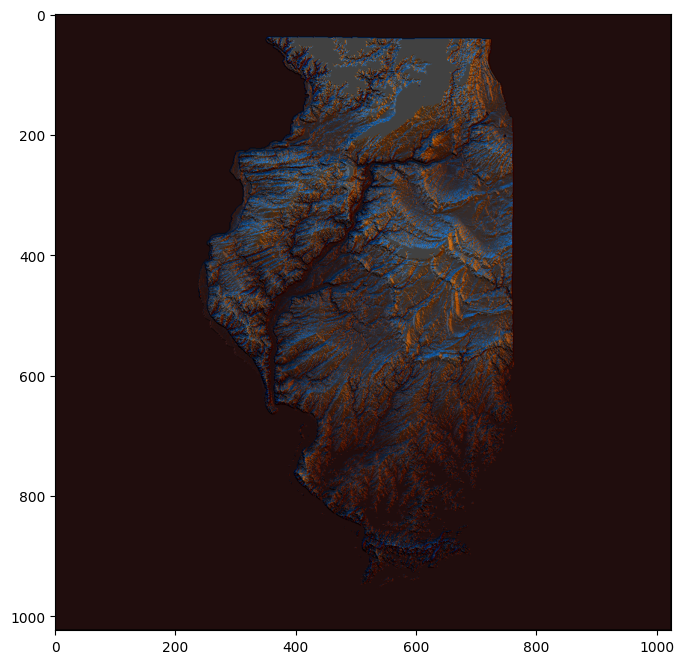

In [117]:
from timeit import default_timer as timer
from ipywidgets import interact, interactive

def draw(exaggeration=30, theta=20, psi=0, k_a=0., k_d=0.5, k_s=0.5, gamma=6):
    start = timer()
    out = render(dem, exaggeration, theta, psi, k_a, k_d, k_s, gamma)
    end = timer()
    print(f'Render time: {end - start}s', end='\r')
    plt.figure('naive', figsize=(8,8))
    plt.imshow(out)

draw()

In [118]:
widget = interactive(draw, exaggeration=(0,50), theta=(0,90), psi=(0,360), k_a=(0,1.), k_d=(0,1.), k_s=(0,1.), gamma=(1,10))
widget.children[-1].layout.height = '8in'
widget

interactive(children=(IntSlider(value=30, description='exaggeration', max=50), IntSlider(value=20, description…